TITANIC DATASET - DATA CLEANING & EDA

1. DATASET OVERVIEW
Shape: (891, 12)

Column Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Basic Statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.00

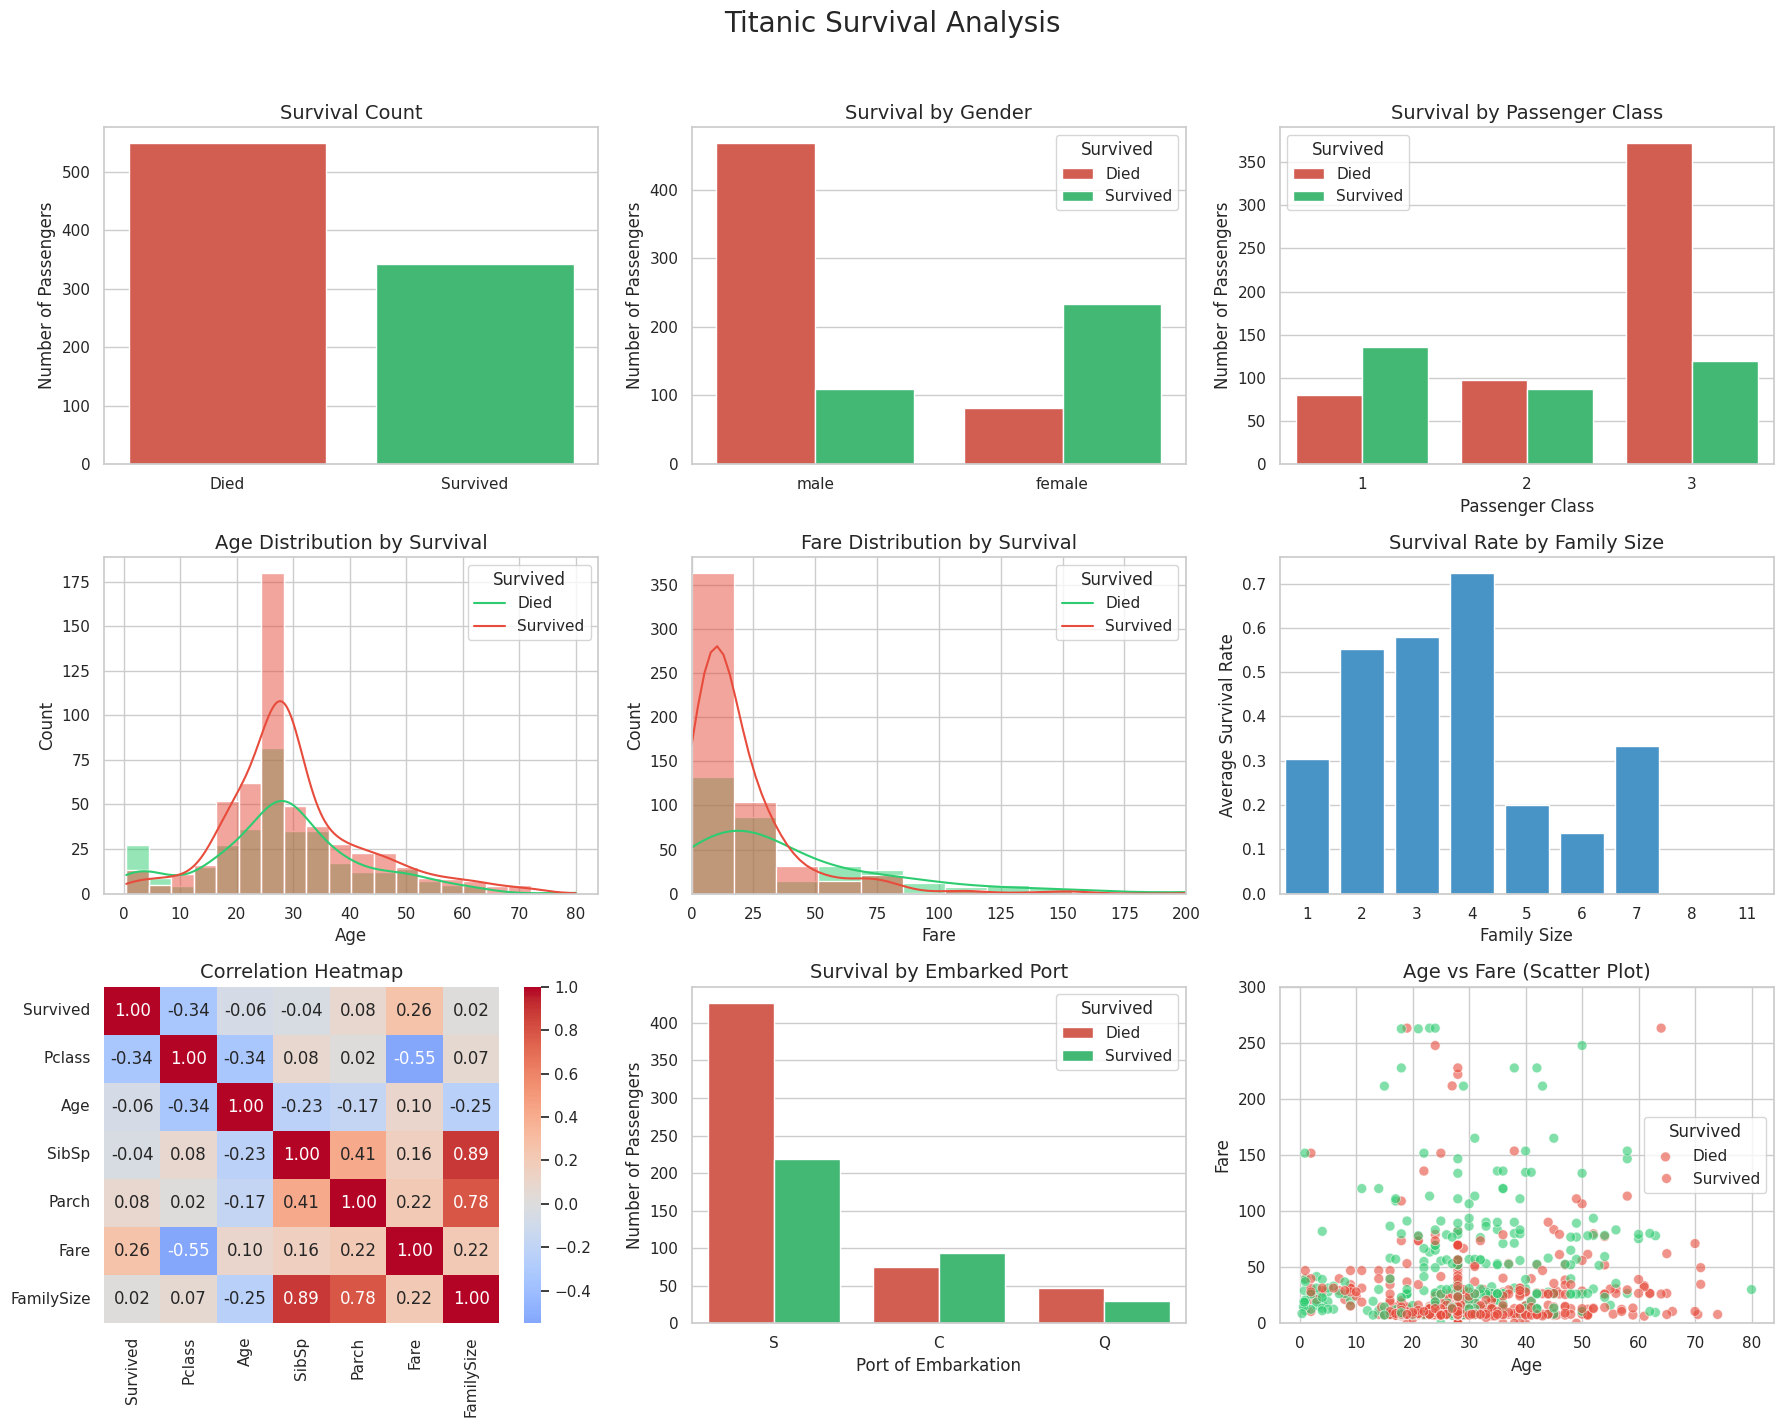

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


sns.set_theme(style="whitegrid")

survival_palette = {0: "#e74c3c", 1: "#2ecc71"}


df = pd.read_csv('train.csv')

print("="*60)
print("TITANIC DATASET - DATA CLEANING & EDA")
print("="*60)


print("\n1. DATASET OVERVIEW")
print(f"Shape: {df.shape}")
print(f"\nColumn Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nBasic Statistics:\n{df.describe()}")


print("\n2. DATA CLEANING")
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop('Cabin', axis=1, inplace=True)
print(f"After cleaning - Missing values:\n{df.isnull().sum()}")


df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

print("\n3. KEY INSIGHTS")
print(f"Survival Rate: {df['Survived'].mean():.2%}")
print(f"\nSurvival by Gender:\n{df.groupby('Sex')['Survived'].agg(['mean', 'count'])}")
print(f"\nSurvival by Class:\n{df.groupby('Pclass')['Survived'].agg(['mean', 'count'])}")
print(f"\nSurvival by Embarked:\n{df.groupby('Embarked')['Survived'].agg(['mean', 'count'])}")


fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Titanic Survival Analysis', fontsize=20)
axes = axes.flatten()


sns.countplot(x='Survived', data=df, palette=survival_palette, ax=axes[0], hue='Survived', legend=False)
axes[0].set_title('Survival Count', fontsize=14)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Died', 'Survived'])
axes[0].set_ylabel('Number of Passengers')
axes[0].set_xlabel('')


sns.countplot(x='Sex', hue='Survived', data=df, palette=survival_palette, ax=axes[1])
axes[1].set_title('Survival by Gender', fontsize=14)
axes[1].set_ylabel('Number of Passengers')
axes[1].set_xlabel('')
axes[1].legend(title='Survived', labels=['Died', 'Survived'])


sns.countplot(x='Pclass', hue='Survived', data=df, palette=survival_palette, ax=axes[2])
axes[2].set_title('Survival by Passenger Class', fontsize=14)
axes[2].set_ylabel('Number of Passengers')
axes[2].set_xlabel('Passenger Class')
axes[2].legend(title='Survived', labels=['Died', 'Survived'])


sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=20, palette=survival_palette, ax=axes[3])
axes[3].set_title('Age Distribution by Survival', fontsize=14)
axes[3].set_xlabel('Age')
axes[3].set_ylabel('Count')
axes[3].legend(title='Survived', labels=['Died', 'Survived'])


sns.histplot(data=df, x='Fare', hue='Survived', kde=True, bins=30, palette=survival_palette, ax=axes[4])
axes[4].set_title('Fare Distribution by Survival', fontsize=14)
axes[4].set_xlabel('Fare')
axes[4].set_ylabel('Count')
axes[4].set_xlim(0, 200)
axes[4].legend(title='Survived', labels=['Died', 'Survived'])


sns.barplot(x='FamilySize', y='Survived', data=df.groupby('FamilySize')['Survived'].mean().reset_index(), color="#3498db", ax=axes[5])
axes[5].set_title('Survival Rate by Family Size', fontsize=14)
axes[5].set_ylabel('Average Survival Rate')
axes[5].set_xlabel('Family Size')


corr = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[6])
axes[6].set_title('Correlation Heatmap', fontsize=14)


sns.countplot(x='Embarked', hue='Survived', data=df, palette=survival_palette, ax=axes[7])
axes[7].set_title('Survival by Embarked Port', fontsize=14)
axes[7].set_ylabel('Number of Passengers')
axes[7].set_xlabel('Port of Embarkation')
axes[7].legend(title='Survived', labels=['Died', 'Survived'])


sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df, palette=survival_palette, alpha=0.6, s=50, ax=axes[8])
axes[8].set_title('Age vs Fare (Scatter Plot)', fontsize=14)
axes[8].set_xlabel('Age')
axes[8].set_ylabel('Fare')
axes[8].set_ylim(0, 300)
axes[8].legend(title='Survived', labels=['Died', 'Survived'])

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('titanic_eda_professional.png', dpi=300, bbox_inches='tight')
print("\n4. Visualizations saved as 'titanic_eda_professional.png'")


print("\n5. KEY PATTERNS & TRENDS")
print(f"• Women survival rate: {df[df['Sex']=='female']['Survived'].mean():.2%}")
print(f"• Men survival rate: {df[df['Sex']=='male']['Survived'].mean():.2%}")
print(f"• Class 1 survival: {df[df['Pclass']==1]['Survived'].mean():.2%}")
print(f"• Class 3 survival: {df[df['Pclass']==3]['Survived'].mean():.2%}")
print(f"• Children (<18) survival: {df[df['Age']<18]['Survived'].mean():.2%}")
print(f"• Adults (>=18) survival: {df[df['Age']>=18]['Survived'].mean():.2%}")
print(f"• Alone passengers survival: {df[df['IsAlone']==1]['Survived'].mean():.2%}")
print(f"• With family survival: {df[df['IsAlone']==0]['Survived'].mean():.2%}")